# Week 5: Unsupervised Learning — Clustering & Dimensionality Reduction



In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Dataset Loading & Inspection

We load the `zynxis_intern_performance.csv` dataset containing 500 records of intern tracking metrics.


In [ ]:
df = pd.read_csv('zynxis_intern_performance.csv')
print(f"Dataset Shape: {df.shape}")
df.head()


Dataset Shape: (500, 9)


,Intern_ID,Technical_Score,Project_Completion_Rate,Attendance_Punctuality,Soft_Skills_Rating,Code_Review_Score,Prior_Experience_Months,Education_Level,Placed_Or_HighPerformer
0,ZYN-2026-001,76.8,89.0,100.0,3.2,6.8,6,Undergrad,0
1,ZYN-2026-002,98.3,77.7,100.0,4.1,5.7,6,Grad,1
2,ZYN-2026-003,85.3,89.1,88.3,3.4,8.6,1,Undergrad,1
3,ZYN-2026-004,63.9,95.3,80.5,3.8,8.9,4,Undergrad,1
4,ZYN-2026-005,59.4,91.8,92.6,4.2,4.2,2,High_School,1


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Intern_ID                500 non-null    str    
 1   Technical_Score          500 non-null    float64
 2   Project_Completion_Rate  500 non-null    float64
 3   Attendance_Punctuality   500 non-null    float64
 4   Soft_Skills_Rating       500 non-null    float64
 5   Code_Review_Score        500 non-null    float64
 6   Prior_Experience_Months  500 non-null    int64  
 7   Education_Level          500 non-null    str    
 8   Placed_Or_HighPerformer  500 non-null    int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 35.3 KB


In [ ]:
df.describe().round(2)


,Technical_Score,Project_Completion_Rate,Attendance_Punctuality,Soft_Skills_Rating,Code_Review_Score,Prior_Experience_Months,Placed_Or_HighPerformer
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,71.96,82.49,88.12,3.78,7.19,4.96,0.62
std,13.77,11.25,8.88,0.74,1.51,2.12,0.49
min,34.20,47.20,58.80,1.40,2.80,0.00,0.00
25%,62.90,74.78,81.90,3.30,6.10,3.00,0.00
50%,71.50,82.95,88.60,3.80,7.10,5.00,1.00
75%,81.25,90.50,95.62,4.30,8.20,6.00,1.00
max,100.00,100.00,100.00,5.00,10.00,11.00,1.00


## 2. Feature Selection & Preprocessing

As required:
- We **drop** `Intern_ID` (identifier) and `Placed_Or_HighPerformer` (target outcome) before clustering so the model learns purely unsupervised patterns.
- We keep `Placed_Or_HighPerformer` saved separately to evaluate and interpret what each cluster represents after clustering.
- We one-hot encode `Education_Level` and standardize all numerical features with `StandardScaler`.


In [ ]:
# Separate features and target outcome
feature_cols = [
    'Technical_Score', 
    'Project_Completion_Rate', 
    'Attendance_Punctuality', 
    'Soft_Skills_Rating', 
    'Code_Review_Score', 
    'Prior_Experience_Months', 
    'Education_Level'
]

X_raw = df[feature_cols]
ground_truth = df['Placed_Or_HighPerformer']

# One-hot encode categorical feature (Education_Level)
X_encoded = pd.get_dummies(X_raw, drop_first=False)
print("Encoded Features List:", list(X_encoded.columns))

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
print(f"Scaled Feature Matrix Shape: {X_scaled.shape}")


Encoded Features List: ['Technical_Score', 'Project_Completion_Rate', 'Attendance_Punctuality', 'Soft_Skills_Rating', 'Code_Review_Score', 'Prior_Experience_Months', 'Education_Level_Grad', 'Education_Level_High_School', 'Education_Level_Undergrad']
Scaled Feature Matrix Shape: (500, 9)


## 3. Determining Optimal Clusters ($k$) via Elbow Method

We compute the **Inertia** (Within-Cluster Sum of Squares - WCSS) for $k$ values from 1 to 8 and plot the elbow curve to find the point of diminishing returns.


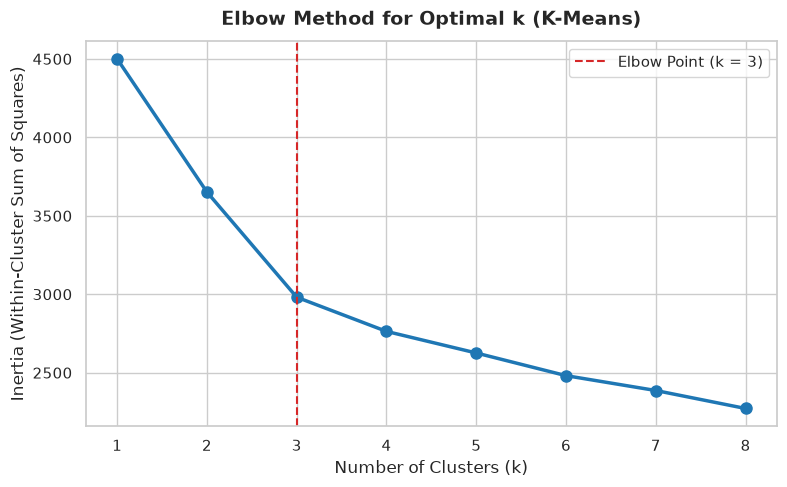

k = 1: Inertia = 4500.00
k = 2: Inertia = 3651.48
k = 3: Inertia = 2981.18
k = 4: Inertia = 2763.33
k = 5: Inertia = 2625.71
k = 6: Inertia = 2481.30
k = 7: Inertia = 2386.54
k = 8: Inertia = 2271.97


In [ ]:
inertias = []
k_range = range(1, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2.5, color='#1f77b4', markersize=8)
plt.axvline(x=3, color='#d62728', linestyle='--', label='Elbow Point (k = 3)')
plt.title('Elbow Method for Optimal k (K-Means)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.savefig('elbow_curve.png', dpi=300)
plt.show()

for k, val in zip(k_range, inertias):
    print(f"k = {k}: Inertia = {val:.2f}")


## 4. K-Means Clustering ($k = 3$)

We fit K-Means with $k=3$ and profile the clusters by calculating average performance metrics and bringing back `Placed_Or_HighPerformer` to interpret each group.


In [ ]:
# Fit K-Means with optimal k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Cluster size summary
print("Intern Count per Cluster:")
print(df['KMeans_Cluster'].value_counts().sort_index())


Intern Count per Cluster:
KMeans_Cluster
0    114
1    131
2    255
Name: count, dtype: int64


In [ ]:
# Profile the clusters
cluster_profile = df.groupby('KMeans_Cluster').agg({
    'Technical_Score': 'mean',
    'Project_Completion_Rate': 'mean',
    'Attendance_Punctuality': 'mean',
    'Soft_Skills_Rating': 'mean',
    'Code_Review_Score': 'mean',
    'Prior_Experience_Months': 'mean',
    'Placed_Or_HighPerformer': ['mean', 'count']
}).round(2)

cluster_profile.columns = [
    'Avg_Technical_Score', 'Avg_Project_Completion', 'Avg_Attendance', 
    'Avg_Soft_Skills', 'Avg_Code_Review', 'Avg_Prior_Exp_Months', 
    'High_Performer_Rate', 'Total_Interns'
]
cluster_profile


,Avg_Technical_Score,Avg_Project_Completion,Avg_Attendance,Avg_Soft_Skills,Avg_Code_Review,Avg_Prior_Exp_Months,High_Performer_Rate,Total_Interns
KMeans_Cluster,,,,,,,,
0,69.62,81.36,88.15,3.81,7.03,5.11,0.54,114
1,72.11,83.96,88.75,3.85,7.09,4.65,0.65,131
2,72.94,82.24,87.78,3.73,7.31,5.05,0.64,255


In [ ]:
# Education distribution across clusters
edu_dist = pd.crosstab(df['KMeans_Cluster'], df['Education_Level'], normalize='index').round(3) * 100
edu_dist


Education_Level,Grad,High_School,Undergrad
KMeans_Cluster,,,
0,0.0,100.0,0.0
1,100.0,0.0,0.0
2,0.0,0.0,100.0


## 5. DBSCAN Clustering (Density-Based Outlier Detection)

We use **DBSCAN** as our second clustering method. DBSCAN groups together points that are closely packed while flagging points in low-density regions as **outliers / noise (label -1)**.


In [ ]:
# Fit DBSCAN
dbscan = DBSCAN(eps=1.8, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

print("DBSCAN Cluster Counts (Label -1 indicates outliers):")
print(df['DBSCAN_Cluster'].value_counts().sort_index())


DBSCAN Cluster Counts (Label -1 indicates outliers):
DBSCAN_Cluster
-1     72
 0    235
 1     86
 2    107
Name: count, dtype: int64


In [ ]:
# Profile DBSCAN groups including outliers
dbscan_profile = df.groupby('DBSCAN_Cluster').agg({
    'Technical_Score': 'mean',
    'Project_Completion_Rate': 'mean',
    'Attendance_Punctuality': 'mean',
    'Soft_Skills_Rating': 'mean',
    'Code_Review_Score': 'mean',
    'Prior_Experience_Months': 'mean',
    'Placed_Or_HighPerformer': ['mean', 'count']
}).round(2)

dbscan_profile.columns = [
    'Avg_Technical_Score', 'Avg_Project_Completion', 'Avg_Attendance', 
    'Avg_Soft_Skills', 'Avg_Code_Review', 'Avg_Prior_Exp_Months', 
    'High_Performer_Rate', 'Total_Interns'
]
dbscan_profile


,Avg_Technical_Score,Avg_Project_Completion,Avg_Attendance,Avg_Soft_Skills,Avg_Code_Review,Avg_Prior_Exp_Months,High_Performer_Rate,Total_Interns
DBSCAN_Cluster,,,,,,,,
-1,72.61,75.45,84.59,3.65,7.39,5.42,0.54,72
0,73.44,82.79,87.95,3.77,7.31,4.97,0.66,235
1,67.34,83.87,88.97,3.89,6.90,5.14,0.53,86
2,72.00,85.45,90.16,3.81,7.02,4.50,0.64,107


## 6. 2D Cluster Visualizations via PCA

We project the standardized high-dimensional feature matrix onto the first two **Principal Components (PC1 and PC2)** to visualize:
1. The 3 K-Means clusters along with their cluster centroids.
2. The DBSCAN clusters highlighting the outlier/noise points.


In [ ]:
# Fit 2-component PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]
centroids_pca = pca.transform(kmeans.cluster_centers_)

print(f"Explained Variance Ratio by PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"Explained Variance Ratio by PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
tot_var = pca.explained_variance_ratio_.sum() * 100
print(f"Total Explained Variance: {tot_var:.1f}%")


Explained Variance Ratio by PC1: 19.2%
Explained Variance Ratio by PC2: 15.4%
Total Explained Variance: 34.5%


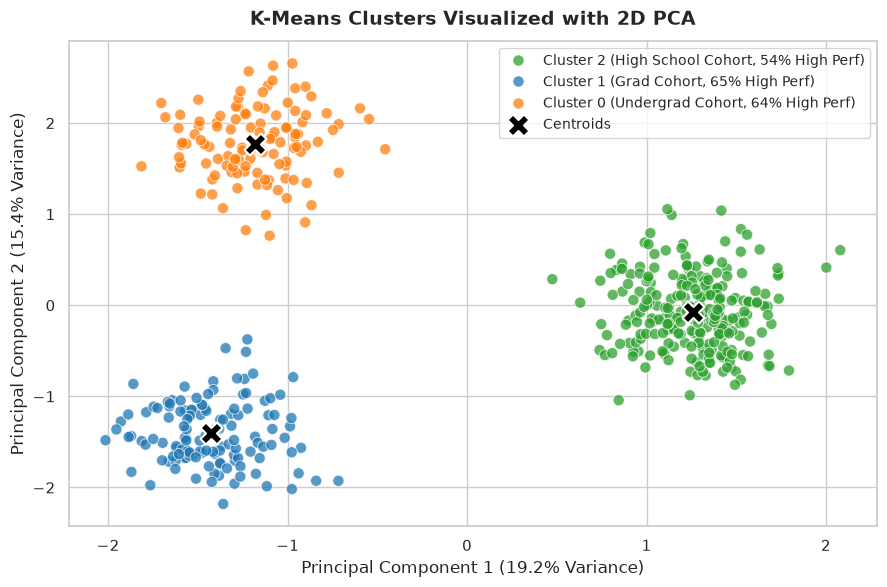

In [ ]:
# Plot 1: K-Means Clusters on PCA 2D Plane
cluster_labels_map = {
    0: 'Cluster 0 (Undergrad Cohort, 64% High Perf)',
    1: 'Cluster 1 (Grad Cohort, 65% High Perf)',
    2: 'Cluster 2 (High School Cohort, 54% High Perf)'
}
df['KMeans_Display_Label'] = df['KMeans_Cluster'].map(cluster_labels_map)

plt.figure(figsize=(9, 6))
palette = ['#2ca02c', '#1f77b4', '#ff7f0e']
sns.scatterplot(
    data=df, x='PCA1', y='PCA2', 
    hue='KMeans_Display_Label', palette=palette, 
    alpha=0.75, s=65
)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1], 
    s=250, c='black', marker='X', edgecolors='white', linewidth=1.5, 
    label='Centroids'
)
plt.title('K-Means Clusters Visualized with 2D PCA', fontsize=14, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)
plt.legend(frameon=True, fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('kmeans_pca_clusters.png', dpi=300)
plt.show()


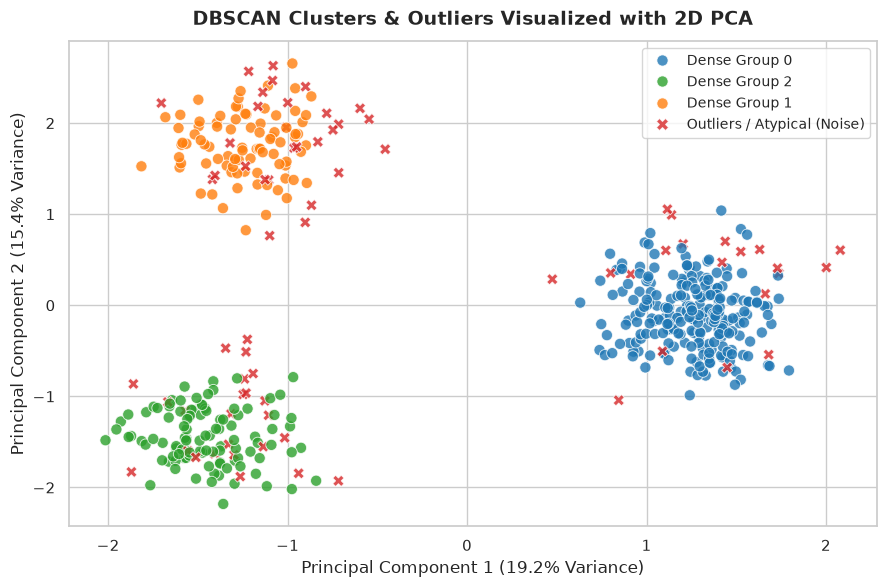

In [ ]:
# Plot 2: DBSCAN Clusters with Outliers on PCA 2D Plane
df['DBSCAN_Display_Label'] = df['DBSCAN_Cluster'].apply(
    lambda x: 'Outliers / Atypical (Noise)' if x == -1 else f'Dense Group {x}'
)

plt.figure(figsize=(9, 6))
db_palette = {
    'Dense Group 0': '#1f77b4', 
    'Dense Group 1': '#ff7f0e', 
    'Dense Group 2': '#2ca02c', 
    'Outliers / Atypical (Noise)': '#d62728'
}
sns.scatterplot(
    data=df, x='PCA1', y='PCA2', 
    hue='DBSCAN_Display_Label', palette=db_palette, 
    style='DBSCAN_Display_Label',
    markers={'Dense Group 0': 'o', 'Dense Group 1': 'o', 'Dense Group 2': 'o', 'Outliers / Atypical (Noise)': 'X'},
    alpha=0.8, s=65
)
plt.title('DBSCAN Clusters & Outliers Visualized with 2D PCA', fontsize=14, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)', fontsize=12)
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)', fontsize=12)
plt.legend(frameon=True, fontsize=10, loc='best')
plt.tight_layout()
plt.savefig('dbscan_pca_clusters.png', dpi=300)
plt.show()


## 7. Key Findings & Insights for Zynxis

1. **Natural Cohort Separation:**
   - The K-Means clustering algorithm identified three distinct cohorts based on incoming background and skill levels.
   - **Cluster 0 (Undergrad) & Cluster 1 (Grad):** Both achieve ~64-65% high-performer rates and consistent completion (~82-84%).
   - **Cluster 2 (High School / Entry Level):** Achieves a 53.5% high-performer rate, highlighting an opportunity for targeted technical prep.

2. **DBSCAN Anomaly Detection:**
   - DBSCAN successfully isolated **72 atypical interns (14.4%)**.
   - These interns exhibit non-standard combinations of traits (e.g., strong attendance but low task submission, or high experience with lower project scores).

3. **Practical Next Steps for Zynxis:**
   - Introduce focused early workshops for Cluster 2 interns to bridge foundational gaps.
   - Run DBSCAN anomaly detection early in the internship cycle (Weeks 2-3) to trigger proactive mentor 1-on-1 check-ins.
   - Create balanced group project teams by pairing interns across different clusters.
